In [2]:
pip install polars matplotlib typing_extensions==4.11.0 great_tables

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.7/109.7 kB 42.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 130.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 201.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 175.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 339.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 150.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 183.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 80.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [14]:
import polars as pl
import matplotlib.pyplot as plt
from great_tables import GT, style, loc
from collections import defaultdict

# Utilities

In [48]:
schema = pl.Schema({"Timers":pl.UInt64(), "TxTime":pl.UInt64(), "RxTime":pl.UInt64()})    

# Configuration

In [10]:
libraries = ["libfabric","native"]
formats = [720,1080,2160]
comp_methods = ["Spin", "Wait"]

# Transfers

## Device to Device Inter-Host

In [44]:
# load data
data_d2d_interhost = defaultdict(lambda: defaultdict(dict))

for library in libraries:
    for format in formats:
        for comp in comp_methods:
            data_d2d_interhost[library][format][comp] = pl.read_csv(f"../data/d2d-interhost/{format}/{library}/MXLFabrics+Cuda2Cuda+Verbs+Reflect+{comp}.csv", schema=schema)["Timers"]


# transform to table view
data_table_d2d_interhost = {"Library":[], "Format":[], "Completion":[], "Mean":[], "Max":[], "STD":[]}
for format in formats:
    for comp in comp_methods:
        for library in libraries:
            y = data_d2d_interhost[library][format][comp]
            
            data_table_d2d_interhost["Library"].append(library)
            data_table_d2d_interhost["Format"].append(format)
            data_table_d2d_interhost["Completion"].append(comp)
            data_table_d2d_interhost["Mean"].append(round(y.mean())/1e6)
            data_table_d2d_interhost["Max"].append(round(y.max())/1e6)
            data_table_d2d_interhost["STD"].append(round(y.std())/1e6)

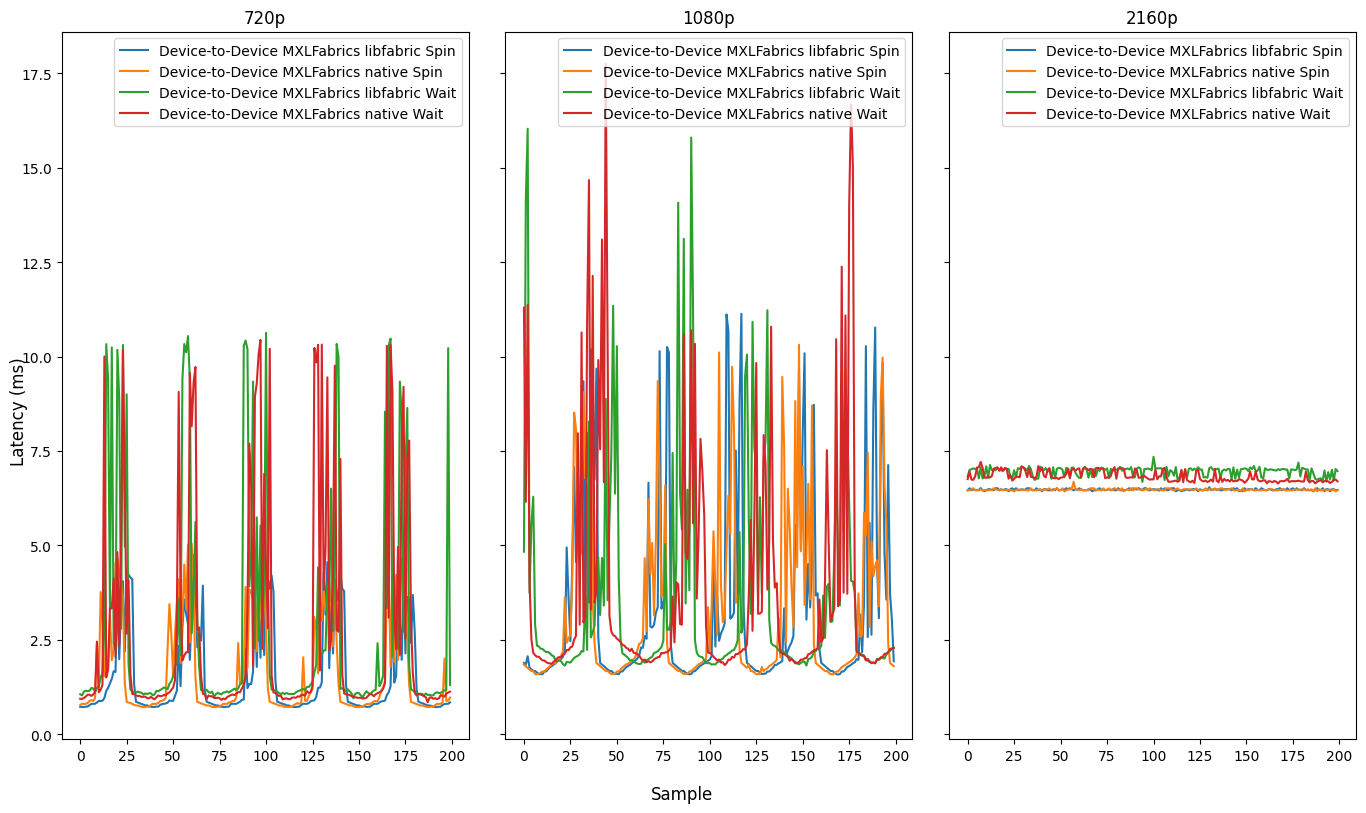

In [45]:
# plot graph
plt.rcParams['figure.figsize'] = [14,8]
fig, axs = plt.subplots(nrows=1,ncols=len(formats), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(formats):
    axs[i].set_title(f"{format}p")
    for comp in comp_methods:
        for library in libraries:
            axs[i].plot(data_d2d_interhost[library][format][comp]/1e6, label=f"Device-to-Device MXLFabrics {library} {comp}")
            axs[i].legend()

In [46]:
# plot table
d2d_interhost_table = GT(pl.DataFrame(data_table_d2d_interhost))
(
    d2d_interhost_table
    .tab_header(
        title="Device-to-Device transfer latency comparison.",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=["Library","Format","Completion"]
    )
    .tab_spanner(
        label="Latency Measurements (ms)",
        columns=["Mean", "Max", "STD"]
    )
    .tab_style(
        style.fill("lightyellow"),
        loc.body(
            columns = pl.selectors.all(),
            rows = pl.col("Max") == pl.col("Max").max()
        )
    )
)


GT(_tbl_data=shape: (12, 6)
┌───────────┬────────┬────────────┬──────────┬───────────┬──────────┐
│ Library   ┆ Format ┆ Completion ┆ Mean     ┆ Max       ┆ STD      │
│ ---       ┆ ---    ┆ ---        ┆ ---      ┆ ---       ┆ ---      │
│ str       ┆ i64    ┆ str        ┆ f64      ┆ f64       ┆ f64      │
╞═══════════╪════════╪════════════╪══════════╪═══════════╪══════════╡
│ libfabric ┆ 720    ┆ Spin       ┆ 1.580553 ┆ 4.748469  ┆ 1.194514 │
│ native    ┆ 720    ┆ Spin       ┆ 1.664336 ┆ 5.049272  ┆ 1.258069 │
│ libfabric ┆ 720    ┆ Wait       ┆ 2.757202 ┆ 10.630522 ┆ 2.951741 │
│ native    ┆ 720    ┆ Wait       ┆ 2.642158 ┆ 10.44339  ┆ 2.879967 │
│ libfabric ┆ 1080   ┆ Spin       ┆ 3.262445 ┆ 11.137009 ┆ 2.502293 │
│ …         ┆ …      ┆ …          ┆ …        ┆ …         ┆ …        │
│ native    ┆ 1080   ┆ Wait       ┆ 3.798509 ┆ 17.759042 ┆ 3.214965 │
│ libfabric ┆ 2160   ┆ Spin       ┆ 6.479925 ┆ 6.541781  ┆ 0.022783 │
│ native    ┆ 2160   ┆ Spin       ┆ 6.477854 ┆ 6.687043  ┆ 0.02522  │
│ libfabric ┆ 2160   ┆ Wait       ┆ 6.96205  ┆ 7.348081  ┆ 0.116382 │
│ native    ┆ 2160   ┆ Wait       ┆ 6.827715 ┆ 7.213181  ┆ 0.139956 │
└───────────┴────────┴────────────┴──────────┴───────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x7d5a4d5c2150>, _boxhead=Boxhead([ColInfo(var='Library', type=<ColInfoTypeEnum.default: 1>, column_label='Library', column_align='left', column_width=None), ColInfo(var='Format', type=<ColInfoTypeEnum.default: 1>, column_label='Format', column_align='right', column_width=None), ColInfo(var='Completion', type=<ColInfoTypeEnum.default: 1>, column_label='Completion', column_align='left', column_width=None), ColInfo(var='Mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='right', column_width=None), ColInfo(var='Max', type=<ColInfoTypeEnum.default: 1>, column_label='Max', column_align='right', column_width=None), ColInfo(var='STD', type=<ColInfoTypeEnum.default: 1>, column_label='STD', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7d5a4d6c7a10>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['Library', 'Format', 'Completion'], built=None), SpannerInfo(spanner_id='Latency Measurements (ms)', spanner_level=0, spanner_label='Latency Measurements (ms)', spanner_units=None, spanner_pattern=None, vars=['Mean', 'Max', 'STD'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison.', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7D5A6403D210>, mask=None), grpname=None, colname='Library', rownum=7, colnum=None, styles=[CellStyleFill(color='lightyellow')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7D5A6403D210>, mask=None), grpname=None, colname='Format', rownum=7, colnum=None, styles=[CellStyleFill(color='lightyellow')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7D5A6403D210>, mask=None), grpname=None, colname='Completion', rownum=7, colnum=None, styles=[CellStyleFill(color='lightyellow')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7D5A6403D210>, mask=None), grpname=None, colname='Mean', rownum=7, colnum=None, styles=[CellStyleFill(color='lightyellow')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7D5A6403D210>, mask=None), grpname=None, colname='Max', rownum=7, colnum=None, styles=[CellStyleFill(color='lightyellow')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7D5A6403D210>, mask=None), grpname=None, colname='STD', rownum=7, colnum=None, styles=[CellStyleFill(color='lightyellow')])], 

## Device to Host 2 Host to Device Inter-host

## Host to Device Intra-Host

## Device to Host Intra-Host

## Device to Device Intra-host Inter-GPU